<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>

# Laboratorium nr 10: Szeregi czasowe. Architektura Transformer.
W poprzednim notatniku wykorzystywaliśmy sieci rekurencyjne (LSTM) wzbogacone o prostą warstwę atencji (Bahdanau Attention), aby skupić uwagę modelu na najistotniejszych elementach sekwencji wejściowej. 

Teraz zrobimy krok naprzód i zaimplementujemy model **Transformer**, który całkowicie rezygnuje z warstw rekurencyjnych na rzecz mechanizmu **Multi-Head Self-Attention**. Transformery przetwarzają całą sekwencję jednocześnie, co znacząco przyspiesza trening, ale wymaga dodatkowego uwzględnienia informacji o kolejności danych (tzw. *Positional Encoding*).

## Import bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import datetime
import matplotlib.pyplot as plt

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Pandas version:", pd.__version__)

2026-04-08 11:13:17.618751: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 11:13:18.617311: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 11:13:20.818258: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Numpy version: 2.4.2
Tensorflow version: 2.20.0
Keras version: 3.13.2
Pandas version: 3.0.1


## Wczytanie danych
Dane o transakcjach umieszczone są w pliku `data_trade_PLKGHM000017.tar.gz'` (do poprania na platformie Delta). Dane są w formacie DataFrame z biblioteki pandas w pliku pickle dodatkowo skompresowane (`gzip`). W pliku znajdują się wszystkie transakcje spółki KGHM z lat 2014-2021.

In [ ]:
df = pd.read_pickle("data_trade_PLKGHM000017.tar.gz")
df["datetime"] = (pd.to_datetime(df["datetime"], unit="ns", utc=True)).dt.tz_convert(
    "Europe/Warsaw"
)
print("Liczba rekordów:", len(df))
df.head()

Liczba rekordów: 10262543


,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
0,2014-01-02 09:00:00.006132+01:00,1,118.8,1,200000000,,,O,B
1,2014-01-02 09:00:00.006141+01:00,2,118.8,10,200000000,,,O,B
2,2014-01-02 09:00:00.006146+01:00,3,118.8,10,200000000,,,O,B
3,2014-01-02 09:00:00.006150+01:00,4,118.8,10,200000000,,,O,B
4,2014-01-02 09:00:00.006154+01:00,5,118.8,10,200000000,,,O,B


## Przygotowanie danych

In [ ]:
sample_x = []
sample_y = []
df_grouped = df.groupby([df["datetime"].dt.date])
for d, g in df_grouped:
    df_day = (
        g.set_index("datetime")
        .resample("1min")
        .agg({"price": "last", "volume": "sum", "trade_id": "count"})
    )
    df_day["price"] = df_day["price"].ffill()
    df_day["volume"] = df_day["volume"].fillna(0)
    df_day["trade_id"] = df_day["trade_id"].fillna(0)
    sample_x.append(df_day.values[:95].copy())
    sample_y.append(df_day.values[-1, 0].copy())

In [ ]:
nsample_x = np.zeros((len(sample_x) - 5, 95, 3))
nsample_y = np.zeros((len(sample_x) - 5))
my = np.zeros((len(sample_x) - 5))
sy = np.zeros((len(sample_x) - 5))
for i in range(5, len(sample_x)):
    dx = sample_x[i - 5 : i]
    dy = sample_y[i - 5 : i]
    mx = np.mean(dx, axis=(0, 1))
    sx = np.std(dx, axis=(0, 1))
    nsample_x[i - 5] = (sample_x[i] - mx) / sx
    mx = np.mean(dy)
    sx = np.std(dy)
    my[i - 5] = mx
    sy[i - 5] = sx
    nsample_y[i - 5] = (sample_y[i] - mx) / sx

nsample_x.shape, nsample_y.shape

((1994, 95, 3), (1994,))

In [ ]:
train_x = nsample_x[: int(0.7 * len(nsample_x))]
train_y = nsample_y[: int(0.7 * len(nsample_x))]
val_x = nsample_x[int(0.7 * len(nsample_x)) : int(0.85 * len(nsample_x))]
val_y = nsample_y[int(0.7 * len(nsample_x)) : int(0.85 * len(nsample_x))]
test_x = nsample_x[int(0.85 * len(nsample_x)) :]
test_y = nsample_y[int(0.85 * len(nsample_x)) :]
train_x.shape, train_y.shape, val_x.shape, val_y.shape, test_x.shape, test_y.shape

((1395, 95, 3), (1395,), (299, 95, 3), (299,), (300, 95, 3), (300,))

## Implementacja bloku Transformera

W przeciwieństwie do bibliotek NLP (gdzie mamy gotowe implementacje), dla szeregów czasowych często budujemy własny blok Enkodera, używając warstwy `MultiHeadAttention`. 
Standardowy blok składa się z:
1. Warstwy `LayerNormalization`
2. Mechanizmu `MultiHeadAttention`
3. Połączenia rezydualnego (Skip connection)
4. Sieci Feed-Forward (złożonej z warstw Dense lub Conv1D z rozmiarem jądra 1)

In [33]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Część 1: Mechanizm Attention i Normalizacja
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Część 2: Sieć Feed-Forward (FFN) i Normalizacja
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

## Model Keras
Model szeregów czasowych oparty na Transformerze wymaga odpowiedniego wstrzyknięcia informacji o czasie (Positional Encoding). Dla uproszczenia, w wielu problemach numerycznych szeregów czasowych, można posłużyć się warstwami Conv1D na początku modelu (jak robiliśmy to poprzednio), które uczą się lokalnych zależności czasowych, zanim przekażą dane do Transformera.

In [ ]:
def build_transformer_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=input_shape)
    # x = inputs
    x = layers.Conv1D(64, 12, strides=3, activation="relu")(inputs)
    # x = layers.Conv1D(128, 10, strides=2, activation='relu')(x)
    # x = layers.Conv1D(128, 5, strides=2, activation='relu')(x)

    # Budowa N bloków Transformera
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # Redukcja wymiarowości (Global Average Pooling działa tu często lepiej niż Flatten)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    # Warstwy klasycznej sieci MLP na końcu
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(1, activation="linear")(x)  # Regresja - prognozowanie ceny
    return keras.Model(inputs, outputs)

In [ ]:
INPUT_SHAPE = (95, 3)

model = build_transformer_model(
    input_shape=INPUT_SHAPE,
    head_size=64,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=2,
    mlp_units=[128],
    mlp_dropout=0.2,
    dropout=0.1,
)

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=1e-4))

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 95, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 28, 64)    │      2,368 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ conv1d_40[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 28, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 28, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 28, 64)    │          0 │ dropout_39[0][0], │
│                     │                   │            │ conv1d_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add_26[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 28, 4)     │        260 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 28, 4)     │          0 │ conv1d_41[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 28, 64)    │        320 │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 28, 64)    │          0 │ conv1d_42[0][0],  │
│                     │                   │            │ add_26[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add_27[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 28, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 28, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 28, 64)    │          0 │ dropout_42[0][0], │
│                     │                   │            │ add_27[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add_28[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 28, 4)     │        260 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 28, 4)     │          0 │ conv1d_43[0][0]   │
│ (Dropout)           │                   │            │                 

 Total params: 140,617 (549.29 KB)

 Trainable params: 140,617 (549.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]

history = model.fit(
    train_x,
    train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/100


2026-04-08 11:32:49.936227: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1769

2026-04-08 11:32:55.158607: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 11:32:55.714659: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4500', 32 bytes spill stores, 32 bytes spill loads



22/22 ━━━━━━━━━━━━━━━━━━━━ -35s -2012992us/step - loss: 5.1227 - val_loss: 4.8133
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6615 - val_loss: 3.3677
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3947 - val_loss: 2.2425
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9247 - val_loss: 2.0890
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8253 - val_loss: 2.0168
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7490 - val_loss: 2.0340
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7521 - val_loss: 1.9968
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.7551 - val_loss: 1.9815
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6731 - val_loss: 1.9872
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6626 - val_loss: 1.9919
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7067 - val_loss: 2.0024
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6780

In [37]:
model.evaluate(test_x, test_y)

 1/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 2.8508

2026-04-08 11:34:39.847228: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 11:34:40.148641: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 8 bytes spill stores, 8 bytes spill loads

2026-04-08 11:34:40.459832: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 1048 bytes spill stores, 1048 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - loss: 1.9964


1.9964308738708496

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

2026-04-08 11:35:39.661873: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 11:35:40.117683: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 8 bytes spill stores, 8 bytes spill loads

2026-04-08 11:35:40.231215: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 1048 bytes spill stores, 1048 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


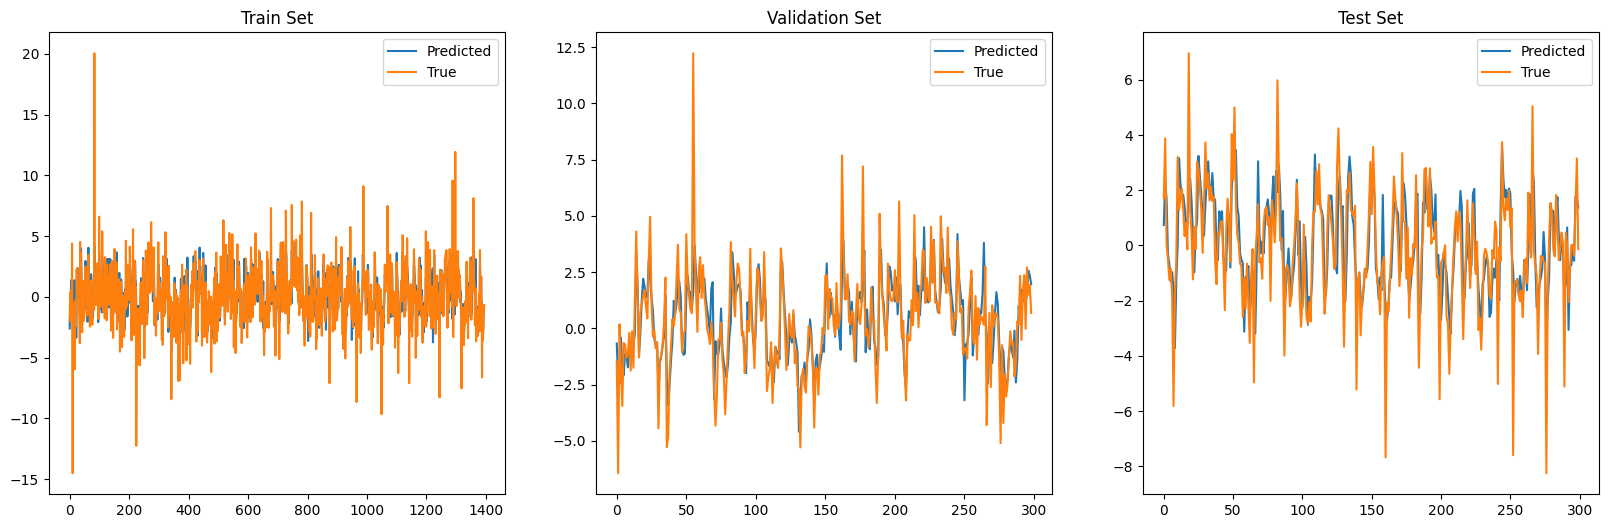

In [39]:
pred1 = model.predict(train_x)
pred2 = model.predict(val_x)
pred3 = model.predict(test_x)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(pred1.flatten(), label="Predicted")
plt.plot(train_y, label="True")
plt.title("Train Set")
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(pred2.flatten(), label="Predicted")
plt.plot(val_y, label="True")
plt.title("Validation Set")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(pred3.flatten(), label="Predicted")
plt.plot(test_y, label="True")
plt.title("Test Set")
plt.legend()
plt.show()

## Ćwiczenia
1. Porównanie z modelem RNN/LSTM: Wytrenuj model Transformer na tych samych oknach czasowych co model z Laboratorium nr 9. Porównaj metryki błędów (MSE, MAE) na zbiorze testowym oraz całkowity czas treningu obu architektur.

2. Strojenie hiperparametrów (Hyperparameter Tuning): Architektura Transformera jest bardzo czuła na hiperparametry. Sprawdź, jak na wynik wpłynie:

    - Zmiana liczby głowic atencji (num_heads = 2, 4, 8).

    - Zwiększenie/zmniejszenie głębokości modelu (num_transformer_blocks).

3. Analiza atencji: Wyprowadź wagi z warstwy MultiHeadAttention (wymaga to modyfikacji wywołania warstwy w Kerasie, aby zwracała `attention_scores`) i spróbuj zwizualizować mapę ciepła (heatmap) pokazującą, na które historyczne transakcje model zwraca największą uwagę podczas predykcji.

4. Positional Encoding: Model z zaimplementowanej dzisiaj postaci nie ma jawnego kodowania pozycji (tzw. vanilla transformer słabo radzi sobie z kolejnością w gołych szeregach numerycznych). Zaimplementuj matematyczny Positional Encoding (funkcje sinus/kosinus) lub dodaj warstwę wektorów zanurzeń (Embedding), aby sprawdzić, czy poprawi to możliwości prognostyczne modelu.